This notebook implements the Reptile meta-learning algorithm for few-shot image classification on the Omniglot dataset. The goal is to train a convolutional neural network such that it can quickly adapt to new classification tasks (5-way, 5-shot) using only a small number of examples per class.

The workflow includes building an episodic task sampler, performing inner-loop adaptation on support sets, and updating a meta-model across many sampled tasks using the Reptile algorithm.

We experiment with different training configurations such as inner-loop learning rate, number of inner steps, meta learning rate, and other hyperparameters to study their impact on generalization. The notebook also includes validation-based model selection and evaluation on unseen test tasks to assess how well the learned initialization transfers to new classes.

In [2]:
import os
print(os.listdir("/kaggle/working"))

['.virtual_documents']


In [3]:
#import shutil

#shutil.copy(
#    "/kaggle/input/datasets/shaikhasifhossain/ckpt-35k/reptile_o55_repo_config_fixed_innerloop_ckpt_35K.pt",
 #   "/kaggle/working/reptile_ckpt.pt"
#)

# Importing Essential Libraries

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random
from torchvision import transforms
import torch.optim as optim
import copy

# Dataset Preprocessing

## Reproducibility, Device Setup, and Image Transformation

In this step, we set up the basic environment for the 5-way 1-shot Reptile experiment.

First, we fix the random seed using the `set_seed()` function. This is important because Reptile depends heavily on random operations such as selecting Omniglot classes, sampling support/query images, and initializing model parameters. By fixing the seed, the experiment becomes easier to reproduce and debug.

Next, we select the computation device. If a GPU is available, the notebook uses CUDA; otherwise, it runs on CPU. Since Reptile repeatedly adapts a model on many sampled tasks, using a GPU makes training much faster.

Finally, we define the image transformation pipeline. Each Omniglot image is resized to `28 × 28` and converted into a PyTorch tensor. Since Omniglot images are grayscale, each transformed image has shape `[1, 28, 28]`.

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [6]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

In [7]:
train_root = "/kaggle/input/datasets/watesoyan/omniglot/images_background"
test_root  = "/kaggle/input/datasets/watesoyan/omniglot/images_evaluation"

In [8]:
import os

def count_images(root_dir):
    count = 0
    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)

        if not os.path.isdir(alphabet_path):
            continue

        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)

            if not os.path.isdir(character_path):
                continue

            count += len(os.listdir(character_path))

    return count


print("Train Samples:", count_images(train_root))
print("Test Samples:", count_images(test_root))

Train Samples: 19280
Test Samples: 13180


In [9]:
def count_images_per_class(root_dir):
    counts = []
    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue

        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)
            if not os.path.isdir(character_path):
                continue

            counts.append(len(os.listdir(character_path)))

    return counts


counts = count_images_per_class(train_root)
print("Min images per class:", min(counts))
print("Max images per class:", max(counts))

Min images per class: 20
Max images per class: 20


## Building the Class-Wise Dataset and Creating Meta-Splits

In this step, we load Omniglot character images and reorganize them into a class-wise dictionary. Each character folder is treated as one class, and all images inside that folder are stored as tensors.

The function `build_class_dict()` goes through each alphabet folder and each character folder, loads the images in grayscale, applies the preprocessing transform, and stores them using a unique class ID.

Both `images_background` and `images_evaluation` are loaded and merged into one larger pool of Omniglot character classes. This is suitable for meta-learning because the model is not learning fixed global labels. Instead, it learns to adapt to newly sampled few-shot tasks. The important condition is that the final meta-training and meta-testing classes must be disjoint.

To avoid accidental name collisions after merging the two folders, a prefix is added to each class ID. For example, a class coming from the background folder is stored as `background/alphabet/character`, while a class from the evaluation folder is stored as `evaluation/alphabet/character`.

After merging, the character classes are shuffled using a fixed seed and split into meta-training and held-out validation/test classes. The validation fraction is set to `0.1`, meaning that 10% of the character classes are held out. In this notebook, the held-out classes are used for both validation and final meta-test evaluation.

The print statements are sanity checks. They show the total number of merged classes, the number of meta-training classes, the number of held-out validation/test classes, and the minimum number of images available per training class.

In [10]:
import os
import random
from PIL import Image


def build_class_dict(root_dir, transform, prefix=""):
    class_dict = {}

    for alphabet in sorted(os.listdir(root_dir)):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue

        for character in sorted(os.listdir(alphabet_path)):
            character_path = os.path.join(alphabet_path, character)
            if not os.path.isdir(character_path):
                continue

            original_images = []
            for img_name in sorted(os.listdir(character_path)):
                img_path = os.path.join(character_path, img_name)
                if not os.path.isfile(img_path):
                    continue

                image = Image.open(img_path).convert("L")
                image_tensor = transform(image)
                original_images.append(image_tensor)
            
            base_class_id = f"{prefix}/{alphabet}/{character}" if prefix else f"{alphabet}/{character}"
            class_dict[base_class_id] = original_images

    return class_dict

background_classes = build_class_dict(train_root, transform, prefix="background")
evaluation_classes = build_class_dict(test_root, transform, prefix="evaluation")

all_classes_full = {}
all_classes_full.update(background_classes)
all_classes_full.update(evaluation_classes)

all_class_ids = list(all_classes_full.keys())
random.seed(42)
random.shuffle(all_class_ids)

val_fraction = 0.1
num_val = int(len(all_class_ids) * val_fraction)

val_class_ids = all_class_ids[-num_val:]
train_class_ids = all_class_ids[:-num_val]

train_classes = {cid: all_classes_full[cid] for cid in train_class_ids}
val_classes = {cid: all_classes_full[cid] for cid in val_class_ids}

test_classes = val_classes

print("All classes:", len(all_classes_full))
print("Meta-train classes:", len(train_classes))
print("Meta-val/test classes:", len(val_classes))

min_images = min(len(v) for v in train_classes.values())
print("Min images per class (train):", min_images)


All classes: 1623
Meta-train classes: 1461
Meta-val/test classes: 162
Min images per class (train): 20


## Sampling Episodic Few-Shot Tasks

In this step, we define the `OmniglotTaskSampler`, which creates few-shot classification tasks from the class-wise Omniglot dictionary.

In meta-learning, the model is not trained on one fixed classification problem. Instead, it repeatedly sees many small tasks. Each task is created by randomly selecting `n_way` character classes. For each selected class, the sampler chooses `k_shot` support images and `q_query` query images.

The support set is used for inner-loop adaptation. This means the copied model learns from the support examples of the current task. The query set is used for evaluation. It checks whether the adapted model can correctly classify new examples from the same selected classes.

The labels are local to each task. For example, in a 5-way task, the randomly selected classes are labelled as `0, 1, 2, 3, 4`. These labels change from task to task and do not represent permanent Omniglot class labels.

For the final 5-way 1-shot evaluation, we use `n_way=5`, `k_shot=1`, and `q_query=5`. This means each task has 5 support images in total and 25 query images in total

In [11]:
import random
import torch

class OmniglotTaskSampler:
    def __init__(self, class_to_images):
        self.class_to_images = class_to_images
        self.class_ids = list(class_to_images.keys())

    def sample_task(self, n_way=5, k_shot=10, q_query=5):
        """
        Sample one N-way K-shot task.

        Returns:
            support_x: tensor of shape [n_way * k_shot, 1, 28, 28]
            support_y: tensor of shape [n_way * k_shot]
            query_x:   tensor of shape [n_way * q_query, 1, 28, 28]
            query_y:   tensor of shape [n_way * q_query]
        """

        selected_classes = random.sample(self.class_ids, n_way)

        support_images = []
        support_labels = []
        query_images = []
        query_labels = []

        for local_label, class_id in enumerate(selected_classes):
            images = self.class_to_images[class_id]
            total_needed = k_shot + q_query

            if len(images) < total_needed:
                raise ValueError(
                    f"Class {class_id} has only {len(images)} images, "
                    f"but {total_needed} are required."
                )

            sampled_images = random.sample(images, total_needed)

            support_imgs = sampled_images[:k_shot]
            query_imgs = sampled_images[k_shot:]

            support_images.extend(support_imgs)
            query_images.extend(query_imgs)

            support_labels.extend([local_label] * k_shot)
            query_labels.extend([local_label] * q_query)

        support_x = torch.stack(support_images)
        support_y = torch.tensor(support_labels, dtype=torch.long)

        query_x = torch.stack(query_images)
        query_y = torch.tensor(query_labels, dtype=torch.long)

        return support_x, support_y, query_x, query_y

In [12]:
train_sampler = OmniglotTaskSampler(train_classes)
val_sampler = OmniglotTaskSampler(val_classes)
test_sampler = OmniglotTaskSampler(test_classes)

In [13]:
import matplotlib.pyplot as plt

def visualize_task(support_x, support_y, query_x, query_y, n_way=5, k_shot=None, q_query=5):

    if k_shot is None:
        k_shot = len(support_x) // n_way  # auto-infer

    total_cols = max(n_way * k_shot, n_way * q_query)

    plt.figure(figsize=(15, 4))

    #Support set
    for i in range(n_way * k_shot):
        plt.subplot(2, total_cols, i + 1)
        plt.imshow(support_x[i].squeeze(0), cmap="gray")
        plt.title(f"S:{support_y[i].item()}")
        plt.axis("off")

    #Query set
    for i in range(n_way * q_query):
        plt.subplot(2, total_cols, total_cols + i + 1)
        plt.imshow(query_x[i].squeeze(0), cmap="gray")
        plt.title(f"Q:{query_y[i].item()}")
        plt.axis("off")

    plt.suptitle("Support (Top) vs Query (Bottom)")
    plt.tight_layout()
    plt.show()

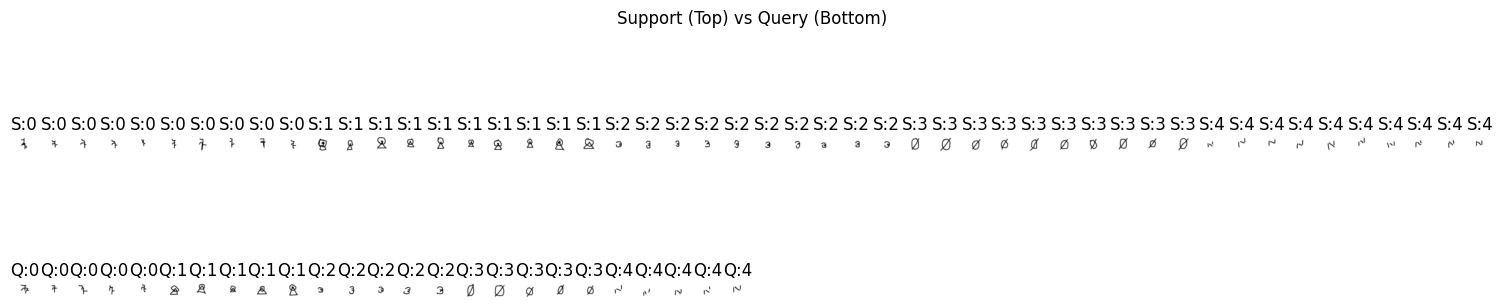

In [14]:
support_x, support_y, query_x, query_y = train_sampler.sample_task(
    n_way=5,
    k_shot=10,   # changed
    q_query=5
)

visualize_task(
    support_x, support_y,
    query_x, query_y,
    n_way=5,
    q_query=5   # k_shot auto-inferred now
)

In [15]:
support_x, support_y, query_x, query_y = train_sampler.sample_task(
    n_way=5,
    k_shot=10,
    q_query=5
)

print("Support labels:", support_y)
print("Query labels:", query_y)
print("Unique support labels:", torch.unique(support_y))
print("Unique query labels:", torch.unique(query_y))

Support labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4])
Query labels: tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
        4])
Unique support labels: tensor([0, 1, 2, 3, 4])
Unique query labels: tensor([0, 1, 2, 3, 4])


In [16]:
print("Support label set:", set(support_y.tolist()))
print("Query label set:", set(query_y.tolist()))

Support label set: {0, 1, 2, 3, 4}
Query label set: {0, 1, 2, 3, 4}


# Model 

## Sampling Episodic Few-Shot Tasks

In this step, we define the `OmniglotTaskSampler`, which creates few-shot classification tasks from the class-wise Omniglot dictionary.

In meta-learning, the model is not trained on one fixed classification problem. Instead, it repeatedly sees many small tasks. Each task is created by randomly selecting `n_way` character classes. For each selected class, the sampler chooses `k_shot` support images and `q_query` query images.

The support set is used for inner-loop adaptation. This means the copied model learns from the support examples of the current task. The query set is used for evaluation. It checks whether the adapted model can correctly classify new examples from the same selected classes.

The labels are local to each task. For example, in a 5-way task, the randomly selected classes are labelled as `0, 1, 2, 3, 4`. These labels change from task to task and do not represent permanent Omniglot class labels.

For the final 5-way 1-shot evaluation, we use `n_way=5`, `k_shot=1`, and `q_query=5`. This means each task has 5 support images in total and 25 query images in total

In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class OmniglotCNN(nn.Module):
    def __init__(self, n_way):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 64),    
            ConvBlock(64, 64),   
            ConvBlock(64, 64), 
            ConvBlock(64, 64)    
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 2 * 2, n_way),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        log_probs = self.classifier(x)
        return log_probs


## Inner-Loop Adaptation with Mini-Batch Updates

In this step, we define the inner-loop adaptation procedure used by Reptile.

The model starts from the current meta-model initialization. For each sampled task, we create a copied task model and adapt it on the support set. This adapted model represents how the meta-model changes after learning one specific task.

The loss function is `NLLLoss` because the CNN outputs log-probabilities using `LogSoftmax`. Therefore, the correct pairing is:

```text
LogSoftmax + NLLLoss

In [18]:
criterion = nn.NLLLoss()


def minibatch_indices(num_support, inner_batch_size, inner_steps, device):
    perm = torch.randperm(num_support, device=device)
    cursor = 0
    for _ in range(inner_steps):
        if cursor + inner_batch_size > num_support:
            perm = torch.randperm(num_support, device=device)
            cursor = 0

        batch_idx = perm[cursor:cursor + inner_batch_size]
        cursor += inner_batch_size
        yield batch_idx


def adapt_on_task(
    meta_model,
    support_x,
    support_y,
    inner_lr=0.001,
    inner_steps=5,
    inner_batch_size=10,
    optimizer_state=None,
    return_optimizer_state=False
):
    support_x = support_x.to(device)
    support_y = support_y.to(device)

    task_model = copy.deepcopy(meta_model)
    task_model.train()

    optimizer = torch.optim.Adam(
        task_model.parameters(),
        lr=inner_lr,
        betas=(0.0, 0.999)
    )

    
    if optimizer_state is not None:
        optimizer.load_state_dict(optimizer_state)

    support_loss_value = None
    num_support = support_x.size(0)

    for batch_idx in _repo_style_minibatch_indices(
        num_support=num_support,
        inner_batch_size=inner_batch_size,
        inner_steps=inner_steps,
        device=device
    ):
        x_batch = support_x[batch_idx]
        y_batch = support_y[batch_idx]

        optimizer.zero_grad()
        log_probs = task_model(x_batch)
        loss = criterion(log_probs, y_batch)
        loss.backward()
        optimizer.step()

        support_loss_value = loss.item()

    if return_optimizer_state:
        return task_model, support_loss_value, optimizer.state_dict()

    return task_model, support_loss_value


## Computing the Reptile Task Delta

In this step, we compute the parameter difference between the adapted task model and the original meta-model.

After inner-loop adaptation, the copied task model has moved from the original meta-model initialization toward parameters that perform better on the sampled task. Reptile uses this movement direction to update the meta-model.

For one sampled task, the task delta is:

$$
\Delta_\tau = \tilde{\phi} - \phi
$$

where:

- $\phi$ is the original meta-model parameter vector.
- $\tilde{\phi}$ is the adapted task-model parameter vector after inner-loop training.
- $\Delta_\tau$ is the direction in which the meta-model should move.

The Reptile outer update then moves the meta-model slightly in this direction:

$$
\phi \leftarrow \phi + \epsilon \Delta_\tau
$$

Since:

$$
\Delta_\tau = \tilde{\phi} - \phi
$$

the update becomes:

$$
\phi \leftarrow \phi + \epsilon(\tilde{\phi} - \phi)
$$

In simple terms, this function measures how the model changed after learning one task. That change is then used as the direction for improving the meta-initialization.

In [19]:
def compute_task_delta(meta_model, task_model):
    return [
        (task_param - meta_param).detach()
        for meta_param, task_param in zip(meta_model.parameters(), task_model.parameters())
    ]

## Evaluating One Few-Shot Task

In this step, we define how to evaluate the meta-model on one sampled few-shot task.

The function receives a support set and a query set. The support set is used for inner-loop adaptation, while the query set is used only for evaluation. This is the standard few-shot learning setup.

First, the current meta-model is adapted on the support examples using `adapt_on_task()`. This creates a task-specific model. Then, the adapted model is evaluated on the query images.

For the 5-way 5-shot setting, this function commonly uses:

- `inner_lr = 0.001`
- `inner_steps = 50`
- `inner_batch_size = 10`

This means that during evaluation, the copied model performs 50 mini-batch Adam updates on the support set before being tested on the query set.

After adaptation, the model is switched to evaluation mode using `task_model.eval()`. This is important because the CNN uses BatchNorm layers. In evaluation mode, the query set is used only to compute predictions and accuracy, not to update BatchNorm statistics.

The function returns two values:

- `query_loss`: the NLL loss on the query set after adaptation.
- `query_acc`: the classification accuracy on the query set after adaptation.

This function measures the main goal of Reptile: after seeing only a small support set, can the model quickly adapt and correctly classify new query examples from the same task?

In [20]:
criterion = nn.NLLLoss()

def evaluate_task(
    meta_model,
    support_x,
    support_y,
    query_x,
    query_y,
    inner_lr=0.001,
    inner_steps=50,
    inner_batch_size=10,
    optimizer_state=None
):
    support_x = support_x.to(device)
    support_y = support_y.to(device)
    query_x = query_x.to(device)
    query_y = query_y.to(device)

    task_model, _ = adapt_on_task(
        meta_model=meta_model,
        support_x=support_x,
        support_y=support_y,
        inner_lr=inner_lr,
        inner_steps=inner_steps,
        inner_batch_size=inner_batch_size,
        optimizer_state=optimizer_state,
        return_optimizer_state=False
    )

    task_model.eval()
    with torch.no_grad():
        query_log_probs = task_model(query_x)
        query_loss = criterion(query_log_probs, query_y).item()
        query_preds = query_log_probs.argmax(dim=1)
        query_acc = (query_preds == query_y).float().mean().item()

    return query_loss, query_acc


## Evaluating Across Many Few-Shot Tasks

In this step, we evaluate the meta-model across many randomly sampled few-shot tasks.

A single sampled task is not enough to judge performance because some Omniglot tasks may be easier or harder depending on which characters are selected. Therefore, we evaluate the model over multiple tasks and report the average query loss and average query accuracy.

For each task, the function:

1. Samples a new few-shot task.
2. Adapts the model on the support set.
3. Evaluates the adapted model on the query set.
4. Stores the query loss and query accuracy.

For the 5-way 5-shot setting, the default configuration is:

- `n_way = 5`
- `k_shot = 5`
- `q_query = 5`
- `inner_lr = 0.001`
- `inner_steps = 50`
- `inner_batch_size = 10`

This means each evaluation task contains 25 support images and 25 query images. The model adapts on the support images and is then tested on the query images. The final returned accuracy is the average accuracy across all sampled tasks.

In [21]:
def evaluate_many_tasks(
    meta_model,
    test_sampler,
    num_tasks=100,
    n_way=5,
    k_shot=5,
    q_query=5,
    inner_lr=0.001,
    inner_steps=50,        
    inner_batch_size=10     
):
    losses = []
    accs = []

    for _ in range(num_tasks):
        support_x, support_y, query_x, query_y = test_sampler.sample_task(
            n_way=n_way,
            k_shot=k_shot,
            q_query=q_query
        )

        query_loss, query_acc = evaluate_task(
            meta_model=meta_model,
            support_x=support_x,
            support_y=support_y,
            query_x=query_x,
            query_y=query_y,
            inner_lr=inner_lr,
            inner_steps=inner_steps,
            inner_batch_size=inner_batch_size   
        )

        losses.append(query_loss)
        accs.append(query_acc)

    avg_loss = sum(losses) / len(losses)
    avg_acc = sum(accs) / len(accs)

    return avg_loss, avg_acc


## Main Reptile Meta-Training Loop for 5-Way 5-Shot

In this step, we define the main Reptile training loop for the 5-way 5-shot Omniglot experiment. This is the central function of the notebook because it connects all previous parts: task sampling, inner-loop adaptation, outer-loop meta-update, validation, checkpointing, and history tracking.

The final 5-way 5-shot configuration uses:

- `n_way = 5`: each task contains 5 classes.
- `train_k_shot = 10`: during meta-training, the model adapts using 10 support examples per class.
- `eval_k_shot = 5`: during validation/testing, the model adapts using 5 support examples per class.
- `q_query = 5`: each class contributes 5 query examples.
- `inner_lr = 0.001`: Adam learning rate for task-specific adaptation.
- `inner_steps = 5`: number of mini-batch optimizer updates during meta-training.
- `eval_inner_steps = 50`: number of mini-batch optimizer updates during evaluation.
- `meta_lr = 0.2 → 0.0`: outer Reptile learning rate linearly annealed during training.
- `tasks_per_meta_batch = 1`: serial Reptile update.

The function first checks whether a checkpoint already exists. If a checkpoint is found, the model resumes from the saved iteration instead of starting from the beginning. This is important because long Reptile training can be interrupted, especially on Kaggle.

During each meta-iteration, the code samples one task, adapts a copied model on the support set, computes the difference between the adapted model and the meta-model, and then moves the meta-model toward the adapted parameters. This is the Reptile outer update.

The function also evaluates the model every fixed number of iterations. During evaluation, the model adapts on validation support sets and is tested on query sets. The best validation model is saved so that the final returned model is the best-performing one, not necessarily the model from the last iteration.

The history dictionary stores training support loss, validation query loss, validation query accuracy, meta-learning-rate values, and best validation accuracy. These values are later used for plotting and analysis.
```


In [22]:
import os
import torch
import copy


def reptile_train(
    meta_model,
    train_sampler,
    val_sampler=None,
    meta_iters=100000,
    tasks_per_meta_batch=1,
    n_way=5,
    train_k_shot=10,
    eval_k_shot=5,
    q_query=5,
    inner_lr=0.001,
    inner_steps=5,
    inner_batch_size=10,
    meta_lr=0.2,
    meta_lr_final=0.0,
    anneal_meta_lr=True,
    eval_every=100,
    eval_tasks=100,
    eval_inner_lr=None,
    eval_inner_steps=50,
    eval_inner_batch_size=10,
    device="cuda",

    # checkpointing
    ckpt_path="/kaggle/working/reptile_o55_repo_config_fixed_innerloop_ckpt.pt",
    block_size=100000
):

    meta_model = meta_model.to(device)

    if eval_inner_lr is None:
        eval_inner_lr = inner_lr

    start_iter = 1
    train_support_losses = []
    eval_query_losses = []
    eval_query_accuracies = []
    meta_lr_history = []

    best_eval_acc = -1.0
    best_model_state = copy.deepcopy(meta_model.state_dict())
    inner_optimizer_state = None

    #load checkpoint
    if os.path.exists(ckpt_path):
        print(f"Loading checkpoint from {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)

        meta_model.load_state_dict(ckpt["model_state"])
        start_iter = ckpt["meta_iter"] + 1

        train_support_losses = ckpt.get("train_support_losses", [])
        eval_query_losses = ckpt.get("eval_query_losses", [])
        eval_query_accuracies = ckpt.get("eval_query_accuracies", [])
        meta_lr_history = ckpt.get("meta_lr_history", [])

        best_eval_acc = ckpt.get("best_eval_acc", -1.0)
        best_model_state = ckpt.get("best_model_state", copy.deepcopy(meta_model.state_dict()))
        inner_optimizer_state = ckpt.get("inner_optimizer_state", None)

        print(f"Resuming from meta_iter = {start_iter}")

    #main loop
    for meta_iter in range(start_iter, meta_iters + 1):
        meta_model.train()

        if anneal_meta_lr:
            frac_done = (meta_iter - 1) / max(1, meta_iters - 1)
            current_meta_lr = (1.0 - frac_done) * meta_lr + frac_done * meta_lr_final
        else:
            current_meta_lr = meta_lr

        delta_sum = [torch.zeros_like(p, device=device) for p in meta_model.parameters()]
        meta_batch_support_losses = []

        for _ in range(tasks_per_meta_batch):
            support_x, support_y, _, _ = train_sampler.sample_task(
                n_way=n_way,
                k_shot=train_k_shot,
                q_query=q_query
            )

            task_model, support_loss_value, inner_optimizer_state = adapt_on_task(
                meta_model=meta_model,
                support_x=support_x,
                support_y=support_y,
                inner_lr=inner_lr,
                inner_steps=inner_steps,
                inner_batch_size=inner_batch_size,
                optimizer_state=inner_optimizer_state,
                return_optimizer_state=True
            )

            meta_batch_support_losses.append(support_loss_value)

            with torch.no_grad():
                for d_sum, meta_p, task_p in zip(delta_sum, meta_model.parameters(), task_model.parameters()):
                    d_sum.add_(task_p - meta_p)

        #reptile outer loop
        with torch.no_grad():
            for meta_p, d_sum in zip(meta_model.parameters(), delta_sum):
                meta_p.add_(current_meta_lr * (d_sum / tasks_per_meta_batch))

        avg_support_loss = sum(meta_batch_support_losses) / len(meta_batch_support_losses)
        train_support_losses.append(avg_support_loss)
        meta_lr_history.append((meta_iter, current_meta_lr))

        #evaluation
        if meta_iter % eval_every == 0:
            sampler = val_sampler if val_sampler is not None else train_sampler

            eval_query_loss, eval_query_acc = evaluate_many_tasks(
                meta_model=meta_model,
                test_sampler=sampler,
                num_tasks=eval_tasks,
                n_way=n_way,
                k_shot=eval_k_shot,
                q_query=q_query,
                inner_lr=eval_inner_lr,
                inner_steps=eval_inner_steps,
                inner_batch_size=eval_inner_batch_size
            )

            eval_query_losses.append((meta_iter, eval_query_loss))
            eval_query_accuracies.append((meta_iter, eval_query_acc))

            print(
                f"[Meta-iter {meta_iter:6d}] "
                f"meta_lr={current_meta_lr:.5f} | "
                f"train_support_loss={avg_support_loss:.4f} | "
                f"eval_query_loss={eval_query_loss:.4f} | "
                f"eval_query_acc={eval_query_acc*100:.2f}%"
            )

            if eval_query_acc > best_eval_acc:
                best_eval_acc = eval_query_acc
                best_model_state = copy.deepcopy(meta_model.state_dict())

        #checkpoints
        if meta_iter % block_size == 0:
            print(f"Saving checkpoint at iter {meta_iter}")

            torch.save({
                "meta_iter": meta_iter,
                "model_state": meta_model.state_dict(),
                "best_model_state": best_model_state,
                "best_eval_acc": best_eval_acc,
                "inner_optimizer_state": inner_optimizer_state,
                "train_support_losses": train_support_losses,
                "eval_query_losses": eval_query_losses,
                "eval_query_accuracies": eval_query_accuracies,
                "meta_lr_history": meta_lr_history,
                "config": {
                    "n_way": n_way,
                    "train_k_shot": train_k_shot,
                    "eval_k_shot": eval_k_shot,
                    "q_query": q_query,
                    "inner_lr": inner_lr,
                    "inner_steps": inner_steps,
                    "inner_batch_size": inner_batch_size,
                    "meta_lr": meta_lr,
                    "meta_lr_final": meta_lr_final,
                    "anneal_meta_lr": anneal_meta_lr,
                    "tasks_per_meta_batch": tasks_per_meta_batch,
                    "eval_inner_steps": eval_inner_steps,
                    "eval_inner_batch_size": eval_inner_batch_size,
                }
            }, ckpt_path)

            print(f"Stopped at {meta_iter}. Run the same cell again to continue.")
            break

    meta_model.load_state_dict(best_model_state)

    history = {
        "train_support_losses": train_support_losses,
        "eval_query_losses": eval_query_losses,
        "eval_query_accuracies": eval_query_accuracies,
        "meta_lr_history": meta_lr_history,
        "best_eval_acc": best_eval_acc
    }

    return meta_model, history


In [23]:
n_way = 5
train_k_shot = 10     
eval_k_shot = 5     
q_query = 5

meta_model = OmniglotCNN(n_way=n_way).to(device)

meta_model, history = reptile_train(
    meta_model=meta_model,
    train_sampler=train_sampler,
    val_sampler=val_sampler,
    meta_iters=100000,
    tasks_per_meta_batch=1,
    n_way=n_way,
    train_k_shot=train_k_shot,
    eval_k_shot=eval_k_shot,
    q_query=q_query,
    inner_lr=0.001,
    inner_steps=5,
    inner_batch_size=10,
    meta_lr=0.2,
    meta_lr_final=0.0,
    anneal_meta_lr=True,
    eval_every=100,
    eval_tasks=100,
    eval_inner_lr=0.001,
    eval_inner_steps=50,
    eval_inner_batch_size=10,
    device=device,
    ckpt_path="/kaggle/working/reptile_o55_repo_config_fixed_innerloop_ckpt.pt",
    block_size=100000
)


[Meta-iter    100] meta_lr=0.19980 | train_support_loss=1.3769 | eval_query_loss=0.6546 | eval_query_acc=78.88%
[Meta-iter    200] meta_lr=0.19960 | train_support_loss=1.1958 | eval_query_loss=0.5397 | eval_query_acc=83.32%
[Meta-iter    300] meta_lr=0.19940 | train_support_loss=0.6205 | eval_query_loss=0.5405 | eval_query_acc=83.32%
[Meta-iter    400] meta_lr=0.19920 | train_support_loss=0.3353 | eval_query_loss=0.4853 | eval_query_acc=84.68%
[Meta-iter    500] meta_lr=0.19900 | train_support_loss=0.6952 | eval_query_loss=0.4962 | eval_query_acc=83.76%
[Meta-iter    600] meta_lr=0.19880 | train_support_loss=1.0800 | eval_query_loss=0.4227 | eval_query_acc=86.60%
[Meta-iter    700] meta_lr=0.19860 | train_support_loss=0.6240 | eval_query_loss=0.4191 | eval_query_acc=87.92%
[Meta-iter    800] meta_lr=0.19840 | train_support_loss=0.6537 | eval_query_loss=0.3788 | eval_query_acc=87.56%
[Meta-iter    900] meta_lr=0.19820 | train_support_loss=0.5893 | eval_query_loss=0.3709 | eval_query_acc

In [24]:
final_test_loss, final_test_acc = evaluate_many_tasks(
    meta_model=meta_model,
    test_sampler=test_sampler,
    num_tasks=1000,
    n_way=5,
    k_shot=5,
    q_query=5,
    inner_lr=0.001,
    inner_steps=50,
    inner_batch_size=10
)

print(f"Final Test Accuracy: {final_test_acc * 100:.2f}%")
print(f"Final Test Loss: {final_test_loss:.4f}")


Final Test Accuracy: 97.23%
Final Test Loss: 0.1202


In [25]:
for steps in [5, 10, 15, 25, 50]:
    test_loss, test_acc = evaluate_many_tasks(
        meta_model,
        test_sampler,
        num_tasks=5000,
        n_way=5,
        k_shot=5,
        q_query=5,
        inner_lr=0.001,
        inner_steps=steps,
        inner_batch_size=10
    )

    print(f"Steps={steps}: {test_acc*100:.2f}%")


Steps=5: 24.88%
Steps=10: 33.66%
Steps=15: 39.70%
Steps=25: 60.09%
Steps=50: 97.30%


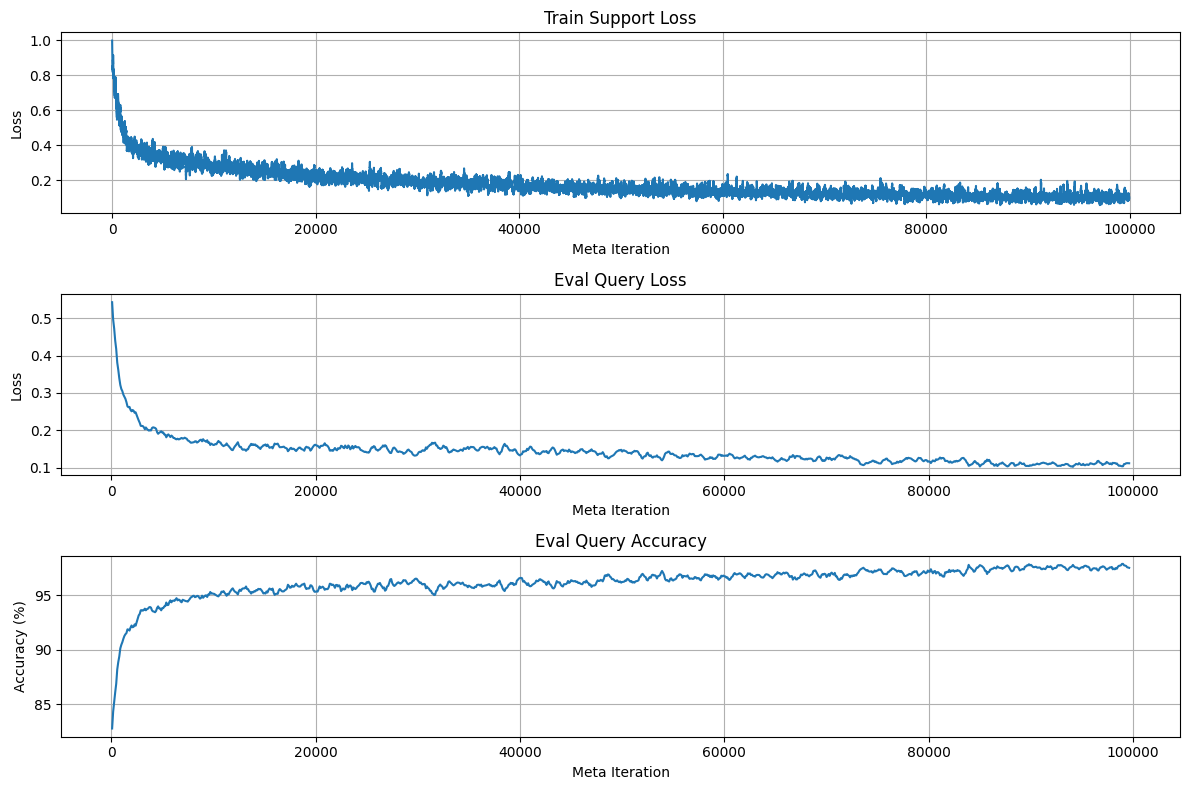

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(x, window=20):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')


# ---- Extract data ----
train_losses = history["train_support_losses"]

eval_meta_iters_loss = [x[0] for x in history["eval_query_losses"]]
eval_losses = [x[1] for x in history["eval_query_losses"]]

eval_meta_iters_acc = [x[0] for x in history["eval_query_accuracies"]]
eval_accs = [x[1] for x in history["eval_query_accuracies"]]


# ---- Smooth curves ----
smooth_train_losses = moving_average(train_losses, window=50)
smooth_eval_losses = moving_average(eval_losses, window=5)
smooth_eval_accs = moving_average(eval_accs, window=5)


# ---- Plot everything together ----
plt.figure(figsize=(12, 8))

# --- Train loss ---
plt.subplot(3, 1, 1)
plt.plot(smooth_train_losses)
plt.title("Train Support Loss")
plt.xlabel("Meta Iteration")
plt.ylabel("Loss")
plt.grid(True)

# --- Eval loss ---
plt.subplot(3, 1, 2)
plt.plot(eval_meta_iters_loss[:len(smooth_eval_losses)], smooth_eval_losses)
plt.title("Eval Query Loss")
plt.xlabel("Meta Iteration")
plt.ylabel("Loss")
plt.grid(True)

# --- Eval accuracy ---
plt.subplot(3, 1, 3)
plt.plot(eval_meta_iters_acc[:len(smooth_eval_accs)], np.array(smooth_eval_accs) * 100)
plt.title("Eval Query Accuracy")
plt.xlabel("Meta Iteration")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

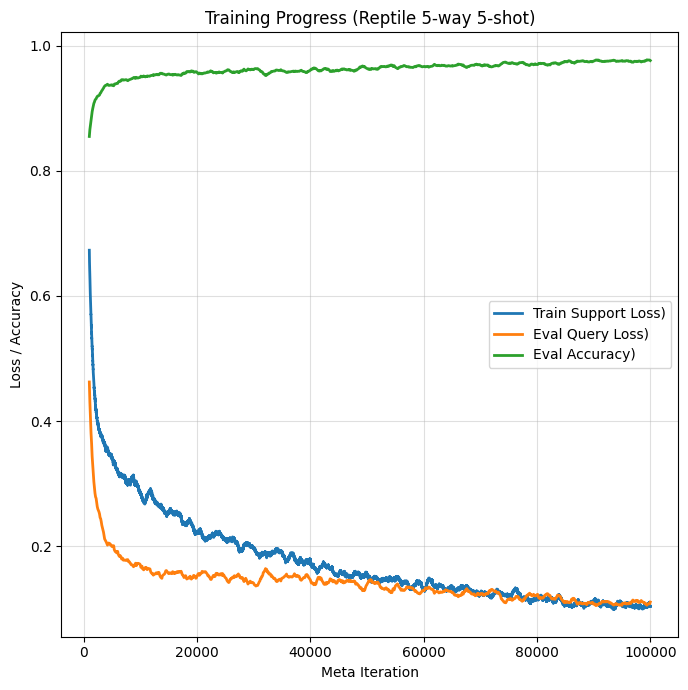

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(x, window=500):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


# ---- Extract data ----
train_losses = np.array(history["train_support_losses"])

eval_meta_iters_loss = np.array([x[0] for x in history["eval_query_losses"]])
eval_losses = np.array([x[1] for x in history["eval_query_losses"]])

eval_meta_iters_acc = np.array([x[0] for x in history["eval_query_accuracies"]])
eval_accs = np.array([x[1] for x in history["eval_query_accuracies"]])


# ---- Smooth ----
train_window = 1000     # increase this if still noisy: 1500 or 2000
eval_window = 10

smooth_train_losses = moving_average(train_losses, window=train_window)
smooth_eval_losses = moving_average(eval_losses, window=eval_window)
smooth_eval_accs = moving_average(eval_accs, window=eval_window)


# Correct x-axis after moving average
train_x = np.arange(1, len(train_losses) + 1)
smooth_train_x = train_x[train_window - 1:]

smooth_eval_loss_x = eval_meta_iters_loss[eval_window - 1:]
smooth_eval_acc_x = eval_meta_iters_acc[eval_window - 1:]


# ---- Plot ----
plt.figure(figsize=(7, 7))

plt.plot(
    smooth_train_x,
    smooth_train_losses,
    label=f"Train Support Loss)",
    linewidth=2
)

plt.plot(
    smooth_eval_loss_x,
    smooth_eval_losses,
    label=f"Eval Query Loss)",
    linewidth=2
)

plt.plot(
    smooth_eval_acc_x,
    smooth_eval_accs,
    label=f"Eval Accuracy)",
    linewidth=2
)

plt.xlabel("Meta Iteration")
plt.ylabel("Loss / Accuracy")
plt.title("Training Progress (Reptile 5-way 5-shot)")
plt.legend()
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

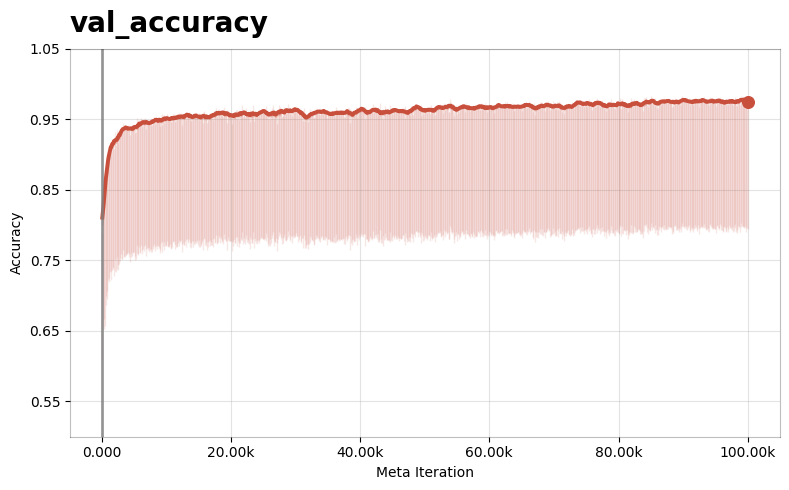

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def moving_average(y, window=9):
    y = np.asarray(y, dtype=float)

    if len(y) < window:
        return y

    pad = window // 2
    y_pad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window

    return np.convolve(y_pad, kernel, mode="valid")


def rolling_std(y, window=9):
    y = np.asarray(y, dtype=float)

    if len(y) < window:
        return np.zeros_like(y)

    stds = []
    half = window // 2

    for i in range(len(y)):
        left = max(0, i - half)
        right = min(len(y), i + half + 1)
        stds.append(np.std(y[left:right]))

    return np.array(stds)


def k_formatter(x, pos):
    if x == 0:
        return "0.000"
    return f"{x/1000:.2f}k"


def plot_pretty_val_accuracy(
    points,
    title="val_accuracy",
    color="#c94f3d",
    smooth_window=9,
    save_path=None
):
    x = np.array([p[0] for p in points])
    y = np.array([p[1] for p in points])

    y_smooth = moving_average(y, smooth_window)
    y_std = rolling_std(y, smooth_window)

    ymin, ymax = 0.50, 1.00

    fig, ax = plt.subplots(figsize=(8, 5))

    # faint vertical variation lines
    for xi, yi in zip(x, y):
        ax.vlines(
            xi,
            ymin=max(ymin, yi - 0.18),
            ymax=yi,
            color=color,
            alpha=0.13,
            linewidth=1
        )

    # soft shaded band
    ax.fill_between(
        x,
        np.clip(y_smooth - 0.5 * y_std, ymin, ymax),
        np.clip(y_smooth + 0.5 * y_std, ymin, ymax),
        color=color,
        alpha=0.18
    )

    # main smooth curve
    ax.plot(
        x,
        y_smooth,
        color=color,
        linewidth=2.8
    )

    # final point marker
    ax.scatter(
        x[-1],
        y_smooth[-1],
        color=color,
        s=70,
        zorder=5
    )

    ax.set_title(title, loc="left", fontsize=20, fontweight="bold", pad=12)
    ax.set_xlabel("Meta Iteration")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.50, 1.05)

    ax.grid(True, alpha=0.35)
    ax.axvline(0, color="gray", linewidth=2, alpha=0.8)

    ax.xaxis.set_major_formatter(FuncFormatter(k_formatter))
    ax.set_yticks(np.arange(0.55, 1.06, 0.10))

    for spine in ax.spines.values():
        spine.set_alpha(0.25)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_pretty_val_accuracy(
    history["eval_query_accuracies"],
    title="val_accuracy",
    color="#c94f3d",
    smooth_window=9,
    save_path="/kaggle/working/reptile_5way5shot_val_accuracy.png"
)

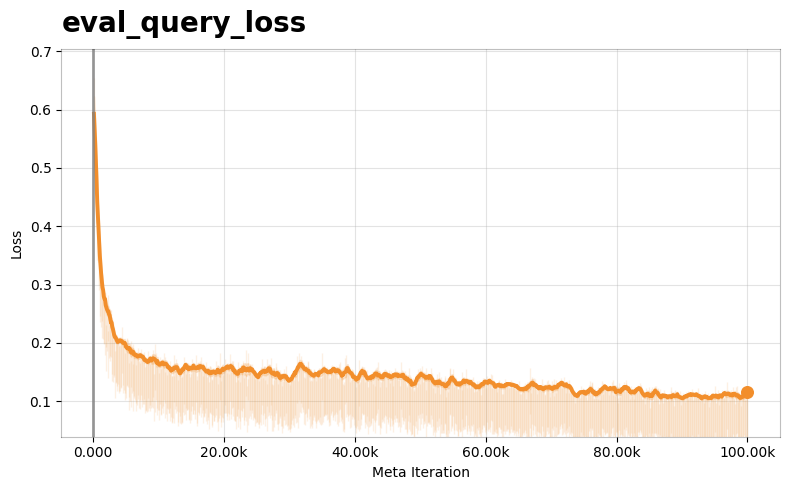

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def moving_average(y, window=9):
    y = np.asarray(y, dtype=float)

    if len(y) < window:
        return y

    pad = window // 2
    y_pad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window

    return np.convolve(y_pad, kernel, mode="valid")


def rolling_std(y, window=9):
    y = np.asarray(y, dtype=float)

    if len(y) < window:
        return np.zeros_like(y)

    stds = []
    half = window // 2

    for i in range(len(y)):
        left = max(0, i - half)
        right = min(len(y), i + half + 1)
        stds.append(np.std(y[left:right]))

    return np.array(stds)


def k_formatter(x, pos):
    if x == 0:
        return "0.000"
    return f"{x/1000:.2f}k"


def plot_pretty_eval_loss(
    points,
    title="eval_query_loss",
    color="#f28e2b",
    smooth_window=9,
    save_path=None
):
    x = np.array([p[0] for p in points])
    y = np.array([p[1] for p in points])

    y_smooth = moving_average(y, smooth_window)
    y_std = rolling_std(y, smooth_window)

    ymin = max(0.0, y.min() - 0.05)
    ymax = y.max() + 0.05

    fig, ax = plt.subplots(figsize=(8, 5))

    # faint vertical variation lines
    for xi, yi in zip(x, y):
        ax.vlines(
            xi,
            ymin=max(ymin, yi - 0.08),
            ymax=yi,
            color=color,
            alpha=0.13,
            linewidth=1
        )

    # soft shaded band
    ax.fill_between(
        x,
        np.clip(y_smooth - 0.5 * y_std, ymin, ymax),
        np.clip(y_smooth + 0.5 * y_std, ymin, ymax),
        color=color,
        alpha=0.18
    )

    # main smooth curve
    ax.plot(
        x,
        y_smooth,
        color=color,
        linewidth=2.8
    )

    # final point marker
    ax.scatter(
        x[-1],
        y_smooth[-1],
        color=color,
        s=70,
        zorder=5
    )

    ax.set_title(title, loc="left", fontsize=20, fontweight="bold", pad=12)
    ax.set_xlabel("Meta Iteration")
    ax.set_ylabel("Loss")
    ax.set_ylim(ymin, ymax)

    ax.grid(True, alpha=0.35)
    ax.axvline(0, color="gray", linewidth=2, alpha=0.8)

    ax.xaxis.set_major_formatter(FuncFormatter(k_formatter))

    for spine in ax.spines.values():
        spine.set_alpha(0.25)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_pretty_eval_loss(
    history["eval_query_losses"],
    title="eval_query_loss",
    color="#f28e2b",
    smooth_window=9,
    save_path="/kaggle/working/reptile_5way5shot_eval_query_loss.png"
)

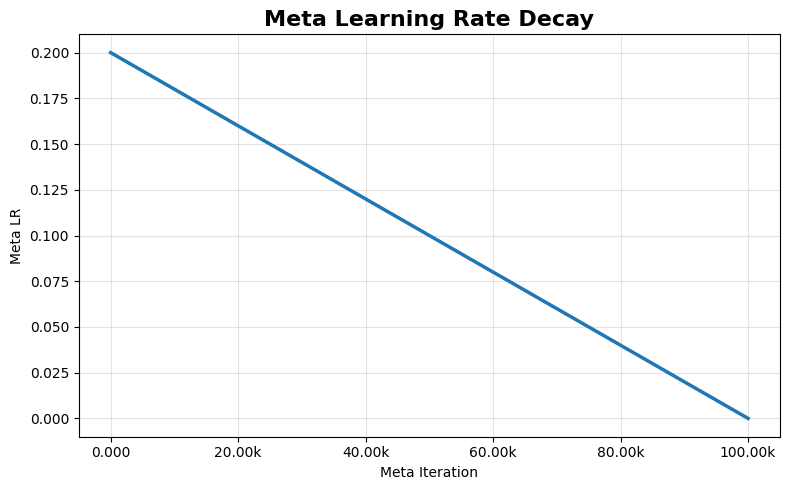

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def k_formatter(x, pos):
    if x == 0:
        return "0.000"
    return f"{x/1000:.2f}k"

meta_iters_lr = np.array([x[0] for x in history["meta_lr_history"]])
meta_lrs = np.array([x[1] for x in history["meta_lr_history"]])

plt.figure(figsize=(8, 5))
plt.plot(meta_iters_lr, meta_lrs, linewidth=2.5)
plt.title("Meta Learning Rate Decay", fontsize=16, fontweight="bold")
plt.xlabel("Meta Iteration")
plt.ylabel("Meta LR")
plt.grid(True, alpha=0.35)
plt.gca().xaxis.set_major_formatter(FuncFormatter(k_formatter))
plt.tight_layout()
plt.show()

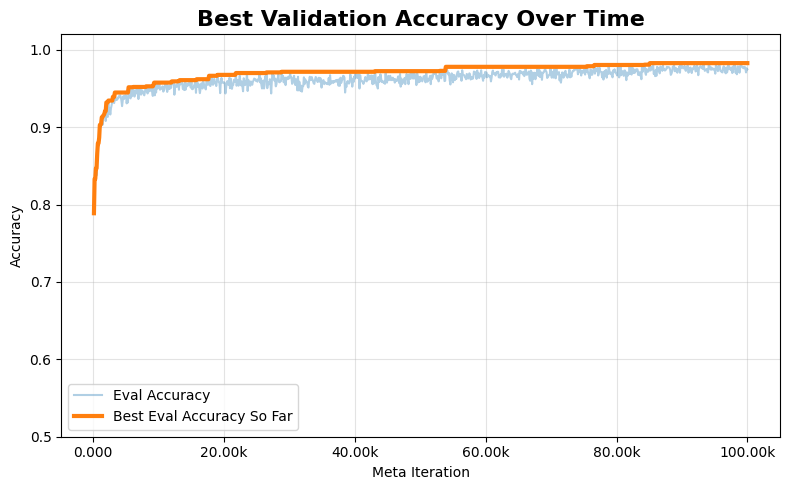

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def k_formatter(x, pos):
    if x == 0:
        return "0.000"
    return f"{x/1000:.2f}k"

eval_iters = np.array([x[0] for x in history["eval_query_accuracies"]])
eval_accs = np.array([x[1] for x in history["eval_query_accuracies"]])

best_so_far = np.maximum.accumulate(eval_accs)

plt.figure(figsize=(8, 5))
plt.plot(eval_iters, eval_accs, alpha=0.35, label="Eval Accuracy")
plt.plot(eval_iters, best_so_far, linewidth=3, label="Best Eval Accuracy So Far")

plt.title("Best Validation Accuracy Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Meta Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.02)
plt.grid(True, alpha=0.35)
plt.legend()
plt.gca().xaxis.set_major_formatter(FuncFormatter(k_formatter))
plt.tight_layout()
plt.show()

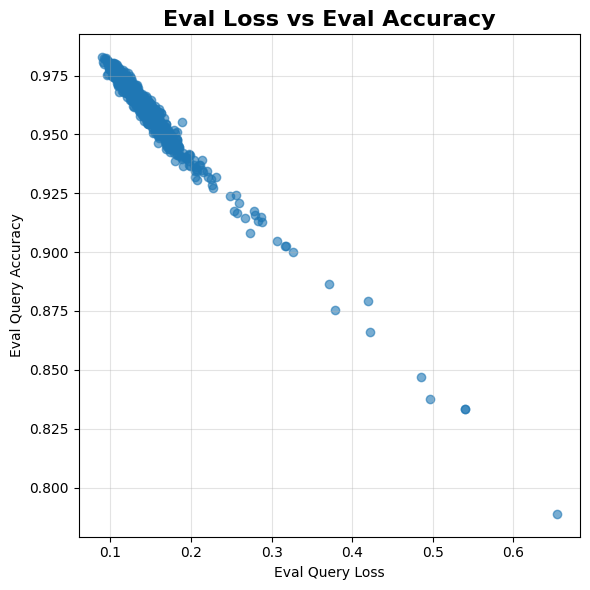

In [41]:
import numpy as np
import matplotlib.pyplot as plt

eval_losses = np.array([x[1] for x in history["eval_query_losses"]])
eval_accs = np.array([x[1] for x in history["eval_query_accuracies"]])

plt.figure(figsize=(6, 6))
plt.scatter(eval_losses, eval_accs, alpha=0.6)
plt.title("Eval Loss vs Eval Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Eval Query Loss")
plt.ylabel("Eval Query Accuracy")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

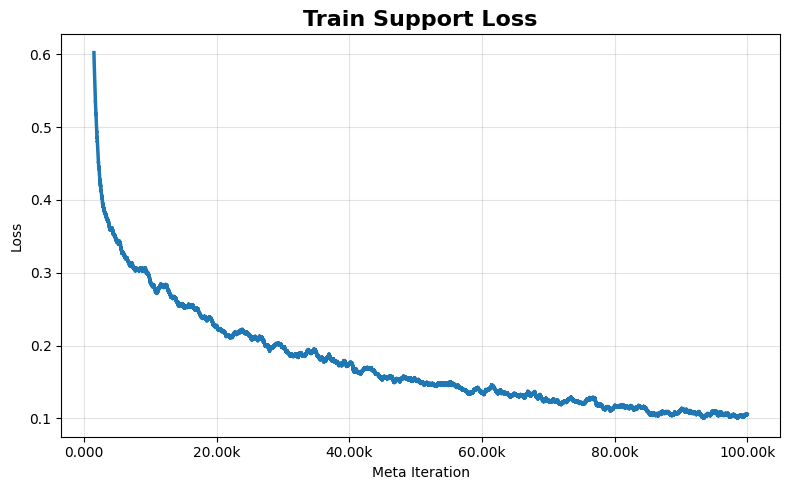

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def moving_average(x, window=1000):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

def k_formatter(x, pos):
    if x == 0:
        return "0.000"
    return f"{x/1000:.2f}k"

train_losses = np.array(history["train_support_losses"])

window = 1500
smooth_train = moving_average(train_losses, window)
smooth_x = np.arange(1, len(train_losses) + 1)[window - 1:]

plt.figure(figsize=(8, 5))
plt.plot(smooth_x, smooth_train, linewidth=2.5)
plt.title("Train Support Loss", fontsize=16, fontweight="bold")
plt.xlabel("Meta Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.35)
plt.gca().xaxis.set_major_formatter(FuncFormatter(k_formatter))
plt.tight_layout()
plt.show()

In [44]:
import torch
import copy

final_save_path = "/kaggle/working/reptile_o55_repo_final_with_history.pt"

torch.save({
    "model_state": meta_model.state_dict(),
    "best_model_state": history.get("best_model_state", None),
    "history": history,
    "best_eval_acc": history.get("best_eval_acc", None),
    "config": {
        "n_way": 5,
        "train_k_shot": 10,
        "eval_k_shot": 5,
        "q_query": 5,
        "inner_lr": 0.001,
        "inner_steps": 5,
        "inner_batch_size": 10,
        "meta_lr": 0.2,
        "meta_lr_final": 0.0,
        "tasks_per_meta_batch": 1,
        "eval_inner_steps": 50,
        "eval_inner_batch_size": 10,
        "meta_iters": 100000,
        "normalization": "BatchNorm2d",
        "architecture": "Repo-style stride-2 Conv + BatchNorm + ReLU"
    }
}, final_save_path)

print("Saved final model + history to:", final_save_path)

Saved final model + history to: /kaggle/working/reptile_o55_repo_final_with_history.pt


In [45]:
history_save_path = "/kaggle/working/reptile_o55_history_only.pt"

torch.save({
    "history": history,
    "config": {
        "n_way": 5,
        "train_k_shot": 10,
        "eval_k_shot": 5,
        "q_query": 5,
        "inner_lr": 0.001,
        "inner_steps": 5,
        "inner_batch_size": 10,
        "meta_lr": 0.2,
        "meta_lr_final": 0.0,
        "tasks_per_meta_batch": 1,
        "eval_inner_steps": 50,
        "eval_inner_batch_size": 10,
        "meta_iters": 100000,
        "normalization": "BatchNorm2d"
    }
}, history_save_path)

print("Saved history to:", history_save_path)

Saved history to: /kaggle/working/reptile_o55_history_only.pt
